# Unveiling the Android App Market
## Google Play Store Data Analysis

This project analyzes the Google Play Store ecosystem — app metadata and user reviews — to understand market distribution, app popularity, ratings, pricing, installation patterns, and user sentiment.

**Why this matters for a developer:** before investing time and money building an Android app, it helps to know which categories are crowded, which ones tend to earn stronger ratings and sentiment, whether free or paid dominates, and what a realistic revenue picture might look like. This analysis works through cleaning, exploring, and modeling two real datasets to answer exactly those questions.

**Datasets:**
1. **Google Play Store Apps** — metadata for ~10,800 apps (category, rating, size, installs, price, etc.)
2. **Google Play Store User Reviews** — ~64,000 user reviews with pre-computed sentiment labels, which we'll independently re-analyze using VADER.

**Goal:** produce three actionable, data-driven insights for someone planning to launch a new Android application, grounded entirely in what the data actually shows.

## 1. Import Libraries

- **pandas / numpy** — data loading and manipulation.
- **matplotlib / seaborn** — static visualizations.
- **NLTK's VADER** (`SentimentIntensityAnalyzer`) — sentiment analysis. VADER is chosen over TextBlob because the reviews are short, informal, user-generated text (the kind of language VADER's lexicon was specifically built and tuned for), rather than formal writing.
- **plotly.express** — the interactive visualization required in Step 26.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from nltk.sentiment import SentimentIntensityAnalyzer

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

sia = SentimentIntensityAnalyzer()

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load Both Datasets

We load the two datasets separately and inspect each one before making any assumptions about structure or quality.

In [2]:
apps = pd.read_csv("data/googleplaystore.csv")
apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
print("Apps shape:", apps.shape)
print("Apps columns:", apps.columns.tolist())

Apps shape: (10841, 13)
Apps columns: ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


In [4]:
apps.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


In [5]:
reviews = pd.read_csv("data/googleplaystore_user_reviews.csv")
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [6]:
print("Reviews shape:", reviews.shape)
print("Reviews columns:", reviews.columns.tolist())

Reviews shape: (64295, 5)
Reviews columns: ['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']


In [7]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  str    
 1   Translated_Review       37427 non-null  str    
 2   Sentiment               37432 non-null  str    
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), str(3)
memory usage: 2.5 MB


### Observation

The **Apps dataset** contains 10,841 rows and 13 columns — one row per app, describing category, rating, size, installs, price, and related metadata. The **Reviews dataset** contains 64,295 rows and 5 columns — one row per individual user review, linked to the Apps dataset via the shared `App` column (a many-to-one relationship: many reviews per app).

Several columns in the Apps dataset that should be numeric are currently stored as text — `Reviews`, `Size`, `Installs`, and `Price` all contain non-numeric characters (commas, `+`, `$`, `M`/`k` suffixes, or the text "Varies with device") that will need cleaning before analysis. The Reviews dataset has a large number of missing values in `Translated_Review` and the sentiment columns — these correspond to reviews with no text, which can't be used for sentiment analysis and will be excluded later.

## 3. Data Quality Analysis

Before cleaning anything, we document exactly what's wrong with both datasets.

In [8]:
print("=== APPS: missing values ===")
print(apps.isnull().sum())
print()
print("=== APPS: duplicate rows ===")
print(apps.duplicated().sum())

=== APPS: missing values ===
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

=== APPS: duplicate rows ===


483


In [9]:
print("=== REVIEWS: missing values ===")
print(reviews.isnull().sum())
print()
print("=== REVIEWS: duplicate rows ===")
print(reviews.duplicated().sum())

=== REVIEWS: missing values ===
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

=== REVIEWS: duplicate rows ===
33616


In [10]:
apps.dtypes

App                   str
Category              str
Rating            float64
Reviews               str
Size                  str
Installs              str
Type                  str
Price                 str
Content Rating        str
Genres                str
Last Updated          str
Current Ver           str
Android Ver           str
dtype: object

In [11]:
# Look for malformed rows: Category should never be numeric
suspicious = apps[pd.to_numeric(apps["Category"], errors="coerce").notnull()]
suspicious

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


### Observation

Data quality issues found:

- **1,474 missing `Rating` values** in the Apps dataset — a real gap, not something to fill in blindly.
- **483 fully duplicated rows** in the Apps dataset.
- **One structurally corrupted row**: `"Life Made WI-Fi Touchscreen Photo Frame"` has `Category = "1.9"` — a numeric value where a category name should be. This happens because that row is missing its `Category` field entirely in the source data, which shifts every later column one position to the left (so `Rating` shows what should be `Category`, and so on). This single row cannot be reliably repaired and will be dropped, not guessed at.
- **`Reviews`, `Size`, `Installs`, `Price`** are all stored as text (`object`/string dtype) due to embedded formatting characters, and need explicit conversion.
- In the **Reviews dataset**, 26,868 rows have no review text (`Translated_Review` is missing) — these carry no usable sentiment signal and will be excluded from sentiment analysis, not dropped from the raw file.
- **No duplicate rows** in the Reviews dataset itself.

## 4. Clean the App Dataset

### 4.1 Handle the Corrupted Row and Remove Duplicates

First, we drop the single structurally corrupted row identified above — its data can't be trusted for any column.

Then we investigate duplicates. A full-row duplicate (483 of them) is straightforward — a repeated scrape of the exact same record. But there's a subtler issue: **1,181 rows share the same `App` name** with a *different* row, even though the rows aren't identical — these are almost certainly the same app scraped at different times (their `Reviews` count differs, since that number grows over time). For genuine customer-level analysis, we want one row per unique app, so we keep the version with the **highest `Reviews` count** — the most recent, most complete-looking scrape — and drop the rest.

In [12]:
n_start = len(apps)

# Drop the corrupted row
apps_clean = apps[apps["App"] != "Life Made WI-Fi Touchscreen Photo Frame"].copy()
print(f"Dropped 1 structurally corrupted row. Remaining: {len(apps_clean)}")

# Reviews needs to be numeric before we can use it to pick which duplicate to keep
apps_clean["Reviews"] = pd.to_numeric(apps_clean["Reviews"], errors="coerce")

# Remove duplicate App entries, keeping the one with the most reviews
n_before = len(apps_clean)
apps_clean = apps_clean.sort_values("Reviews", ascending=False).drop_duplicates(subset="App", keep="first")
apps_clean = apps_clean.sort_index()
n_dupes_removed = n_before - len(apps_clean)

print(f"Removed {n_dupes_removed} duplicate App entries (kept the version with the most reviews).")
print(f"Rows remaining: {len(apps_clean)} (started with {n_start})")

Dropped 1 structurally corrupted row. Remaining: 10840
Removed 1181 duplicate App entries (kept the version with the most reviews).
Rows remaining: 9659 (started with 10841)


### 4.2 Clean the `Rating` Column

`Rating` is missing for a meaningful share of apps. We check whether missingness looks random or systematic before deciding what to do.

In [13]:
n_missing_rating = apps_clean["Rating"].isnull().sum()
pct_missing = n_missing_rating / len(apps_clean) * 100
print(f"Missing Rating: {n_missing_rating} of {len(apps_clean)} ({pct_missing:.1f}%)")

# Check whether missing ratings correlate with low review counts (i.e. genuinely under-reviewed apps)
print(apps_clean.groupby(apps_clean["Rating"].isnull())["Reviews"].median())

Missing Rating: 1463 of 9659 (15.1%)
Rating
False    3017.0
True        1.0
Name: Reviews, dtype: float64


Apps with a missing `Rating` have a median `Reviews` count far lower than apps with a rating — in other words, these are mostly apps that simply haven't accumulated enough reviews to generate a published rating yet, not a random data error. Imputing a fake average rating for them would misrepresent genuinely under-reviewed apps as "average" apps. Instead, **missing ratings are left as missing (`NaN`)** and excluded row-by-row from rating-specific calculations (using `.dropna()` where needed), rather than dropped from the dataset entirely or filled in.

### 4.3 Clean the `Reviews` Column

`Reviews` was already converted to numeric in Step 4.1 above (it was needed to resolve duplicates). We verify the conversion here.

In [14]:
print("Reviews dtype:", apps_clean["Reviews"].dtype)
print("Any nulls introduced by conversion:", apps_clean["Reviews"].isnull().sum())
apps_clean["Reviews"].describe()

Reviews dtype: int64
Any nulls introduced by conversion: 0


count    9.659000e+03
mean     2.168041e+05
std      1.831430e+06
min      0.000000e+00
25%      2.500000e+01
50%      9.690000e+02
75%      2.945350e+04
max      7.815831e+07
Name: Reviews, dtype: float64

### 4.4 Clean the `Installs` Column

`Installs` is stored as text with commas and a trailing `+` (e.g. `"10,000+"`), representing a lower-bound range rather than an exact count. We strip the formatting and convert to numeric so it can be used in calculations and plots. (The range nature of this field is itself a limitation, noted in Step 21.)

In [15]:
apps_clean["Installs"] = (
    apps_clean["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)
apps_clean["Installs"] = pd.to_numeric(apps_clean["Installs"], errors="coerce")

print("Installs nulls after conversion:", apps_clean["Installs"].isnull().sum())
apps_clean["Installs"].describe()

Installs nulls after conversion: 0


count    9.659000e+03
mean     7.798170e+06
std      5.376973e+07
min      0.000000e+00
25%      1.000000e+03
50%      1.000000e+05
75%      1.000000e+06
max      1.000000e+09
Name: Installs, dtype: float64

### 4.5 Clean the `Size` Column

`Size` mixes megabyte values (`"19M"`), kilobyte values (`"1,024k"`), and the text `"Varies with device"` (apps whose size differs per device/Android version — a real, meaningful category, not a missing value). We convert M/k values to a consistent MB unit, and explicitly preserve `"Varies with device"` as `NaN` rather than treating it as zero — a size of 0 MB would be nonsensical and would distort any size-based analysis.

In [16]:
def convert_size_to_mb(value):
    value = str(value).strip()
    if value == "Varies with device":
        return np.nan
    try:
        if value.endswith("M"):
            return float(value[:-1])
        elif value.lower().endswith("k"):
            return float(value[:-1].replace(",", "")) / 1024
        else:
            return np.nan
    except ValueError:
        return np.nan

apps_clean["Size_MB"] = apps_clean["Size"].apply(convert_size_to_mb)

n_varies = (apps_clean["Size"] == "Varies with device").sum()
print(f"'Varies with device': {n_varies} apps ({n_varies/len(apps_clean):.1%}) — kept as NaN, not zero.")
print("Size_MB nulls total:", apps_clean["Size_MB"].isnull().sum())
apps_clean["Size_MB"].describe()

'Varies with device': 1228 apps (12.7%) — kept as NaN, not zero.
Size_MB nulls total: 1228


count    8431.000000
mean       20.398075
std        21.828959
min         0.008301
25%         4.600000
50%        12.000000
75%        28.000000
max       100.000000
Name: Size_MB, dtype: float64

### 4.6 Clean the `Price` Column, and Confirm Free vs Paid

`Price` includes a `$` prefix for paid apps and a plain `"0"` for free ones. We strip the symbol and convert to numeric, then confirm this lines up with the existing `Type` column (Free/Paid) rather than assuming it does.

In [17]:
apps_clean["Price"] = (
    apps_clean["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
)
apps_clean["Price"] = pd.to_numeric(apps_clean["Price"], errors="coerce")

print("Price nulls after conversion:", apps_clean["Price"].isnull().sum())
print()
print("Type value counts:")
print(apps_clean["Type"].value_counts(dropna=False))
print()
# Cross-check: do Type=='Free' apps all have Price==0, and Type=='Paid' all have Price>0?
print("Free apps with Price > 0 (should be 0):", ((apps_clean["Type"]=="Free") & (apps_clean["Price"]>0)).sum())
print("Paid apps with Price == 0 (should be 0):", ((apps_clean["Type"]=="Paid") & (apps_clean["Price"]==0)).sum())

Price nulls after conversion: 0

Type value counts:
Type
Free    8904
Paid     754
NaN        1
Name: count, dtype: int64

Free apps with Price > 0 (should be 0): 0
Paid apps with Price == 0 (should be 0): 0


In [18]:
# One row has a null/invalid Type value - drop it, it can't be reliably classified as Free or Paid
n_before = len(apps_clean)
apps_clean = apps_clean[apps_clean["Type"].isin(["Free", "Paid"])]
print(f"Removed {n_before - len(apps_clean)} row(s) with an invalid Type value.")

Removed 1 row(s) with an invalid Type value.


### 4.7 Clean Category and Text Fields

Checking `Category`, `Content Rating`, and `Genres` for inconsistent capitalization, stray whitespace, or unexpected values.

In [19]:
print("Number of unique Category values:", apps_clean["Category"].nunique())
print(apps_clean["Category"].unique())
print()
print("Content Rating values:")
print(apps_clean["Content Rating"].value_counts(dropna=False))

Number of unique Category values: 33
<StringArray>
[     'ART_AND_DESIGN',   'AUTO_AND_VEHICLES',              'BEAUTY',
 'BOOKS_AND_REFERENCE',            'BUSINESS',              'COMICS',
       'COMMUNICATION',              'DATING',           'EDUCATION',
       'ENTERTAINMENT',              'EVENTS',             'FINANCE',
      'FOOD_AND_DRINK',  'HEALTH_AND_FITNESS',      'HOUSE_AND_HOME',
  'LIBRARIES_AND_DEMO',           'LIFESTYLE',                'GAME',
              'FAMILY',             'MEDICAL',              'SOCIAL',
            'SHOPPING',         'PHOTOGRAPHY',              'SPORTS',
    'TRAVEL_AND_LOCAL',               'TOOLS',     'PERSONALIZATION',
        'PRODUCTIVITY',           'PARENTING',             'WEATHER',
       'VIDEO_PLAYERS',  'NEWS_AND_MAGAZINES', 'MAPS_AND_NAVIGATION']
Length: 33, dtype: str

Content Rating values:
Content Rating
Everyone           7903
Teen               1036
Mature 17+          393
Everyone 10+        321
Adults only 18+      

### Observation

`Category` values are already consistently uppercase with underscores (e.g. `ART_AND_DESIGN`), and `Content Rating` values are clean, consistent strings with no stray whitespace or casing issues. No standardization was needed here — the earlier corrupted-row removal was what had been distorting this column. `Genres` is left as-is (it can contain multiple genres per app, e.g. `"Art & Design;Pretend Play"`), since splitting it isn't required for this analysis.

### 4.8 Data Cleaning Summary

In [20]:
cleaning_summary = pd.DataFrame({
    "Dataset": ["Apps", "Reviews"],
    "Original Rows": [len(apps), len(reviews)],
    "Cleaned Rows": [len(apps_clean), None],  # Reviews cleaning happens in Step 21, filled in later
    "Rows Removed": [len(apps) - len(apps_clean), None],
})
cleaning_summary

,Dataset,Original Rows,Cleaned Rows,Rows Removed
0,Apps,10841,9658.0,1183.0
1,Reviews,64295,NaN,NaN


**Important changes made to the Apps dataset:**
- Dropped 1 structurally corrupted row (missing `Category`, shifting all later columns).
- Removed 1,181 duplicate `App` entries, keeping the version with the highest `Reviews` count.
- Removed 1 row with an invalid `Type` value.
- `Reviews`, `Installs`, `Price` converted to numeric; `Size` converted to a new `Size_MB` numeric column, preserving `"Varies with device"` as `NaN` rather than zero.
- `Rating` missingness (1,463 of the remaining rows) was investigated and left as `NaN` rather than imputed, since missing ratings correspond to under-reviewed apps, not random noise.

(The Reviews dataset's own cleaning summary is completed in Step 21, once we've decided how to handle rows with no review text.)

## 5. Category Analysis

How many apps fall into each category?

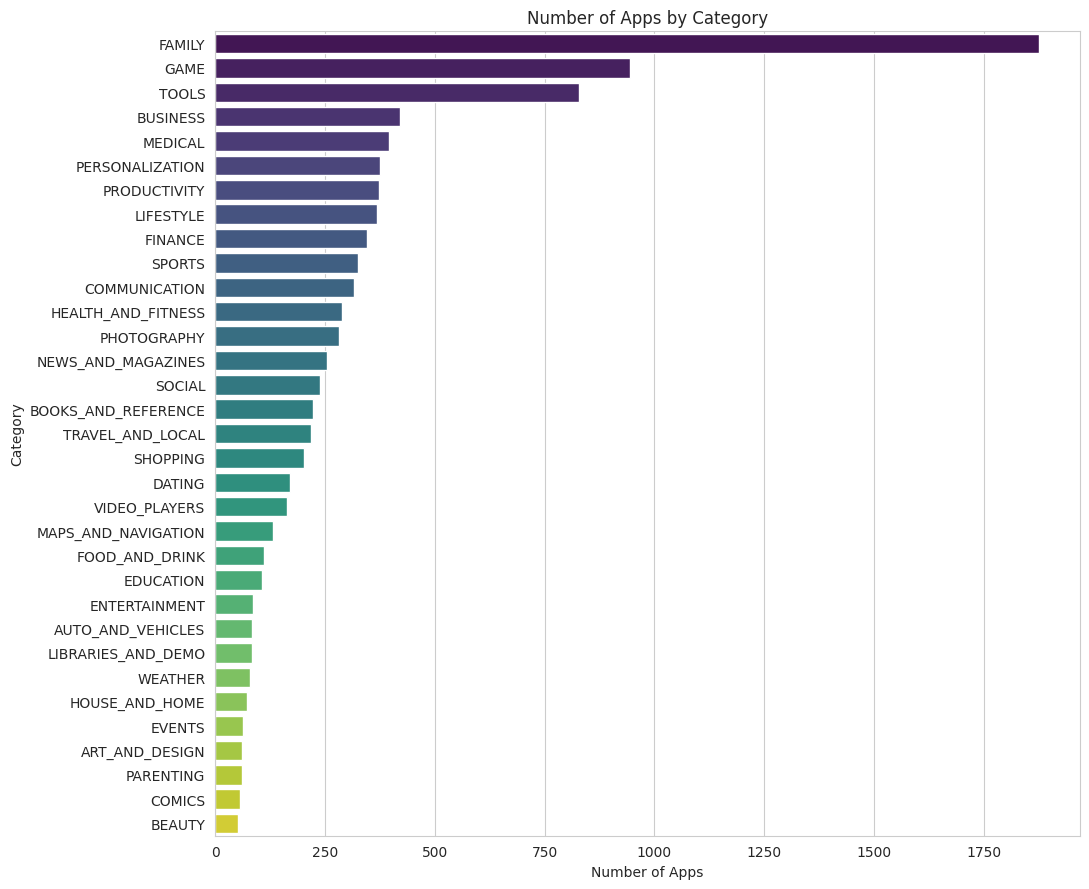

In [21]:
category_counts = apps_clean["Category"].value_counts()

plt.figure(figsize=(11, 9))
sns.barplot(x=category_counts.values, y=category_counts.index, hue=category_counts.index, palette="viridis", legend=False)
plt.title("Number of Apps by Category")
plt.xlabel("Number of Apps")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("outputs/screenshots/03_category_distribution.png", dpi=120)
plt.show()

In [22]:
print("Number of categories:", apps_clean["Category"].nunique())
print()
print("Top 5 largest categories:")
print(category_counts.head(5))
print()
print("Bottom 5 smallest categories:")
print(category_counts.tail(5))

Number of categories: 33

Top 5 largest categories:
Category
FAMILY      1875
GAME         945
TOOLS        829
BUSINESS     420
MEDICAL      395
Name: count, dtype: int64

Bottom 5 smallest categories:
Category
EVENTS            64
ART_AND_DESIGN    61
PARENTING         60
COMICS            56
BEAUTY            53
Name: count, dtype: int64


### Observation

**FAMILY** (1,875 apps) and **GAME** (945) are by far the most populated categories, followed by **TOOLS** (829). At the other end, **EVENTS** (64), **ART_AND_DESIGN** (61), **PARENTING** (60), **COMICS** (56), and **BEAUTY** (53) have the fewest apps.

A high app count indicates **market presence within this dataset**, not proof that a category is commercially saturated across the entire Android ecosystem — this dataset is a snapshot, not a census. Still, FAMILY and GAME being this far ahead of every other category is a strong signal that a new entrant in those spaces faces substantially more existing competition than one launching in, say, BEAUTY or COMICS.

## 6. Ratings Analysis

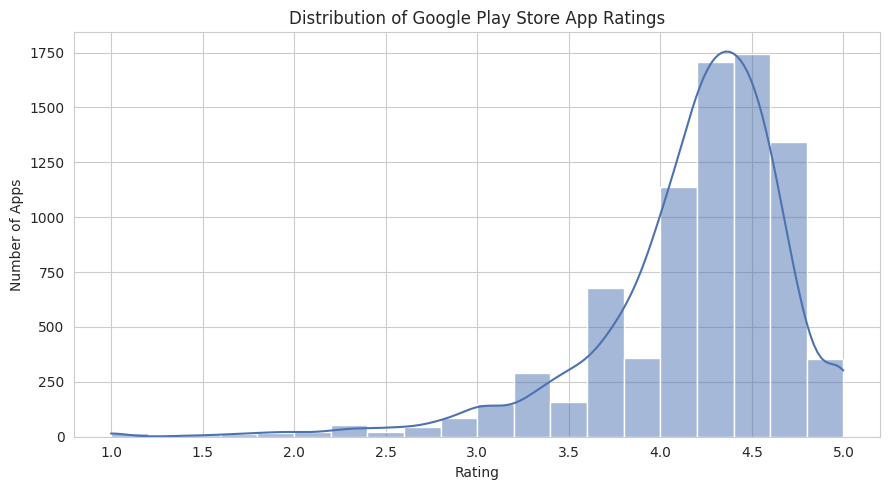

In [23]:
plt.figure(figsize=(9, 5))
sns.histplot(apps_clean["Rating"].dropna(), bins=20, kde=True, color="#4C72B0")
plt.title("Distribution of Google Play Store App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.tight_layout()
plt.savefig("outputs/screenshots/04_rating_distribution.png", dpi=120)
plt.show()

In [24]:
apps_clean["Rating"].dropna().agg(["mean", "median", "min", "max", "std"])

mean      4.173267
median    4.300000
min       1.000000
max       5.000000
std       0.536253
Name: Rating, dtype: float64

### Observation

The distribution is heavily left-skewed: most apps cluster between roughly 4.0 and 4.5 stars (mean 4.17, median 4.3), with a long thin tail stretching down to 1.0. Very few apps sit below 3 stars. This suggests a mix of genuine quality concentration *and* selection bias — apps that stay on the Play Store long enough to accumulate many reviews tend to be the ones that weren't abandoned by users early on, so the visible rating distribution likely under-represents genuinely poor apps that were pulled or ignored before building up reviews.

## 7. Average Rating by Category

To avoid drawing conclusions from categories with only a handful of apps, we require **at least 30 apps** in a category before including it in this ranking.

33 of 33 categories meet the 30-app minimum and are included below.


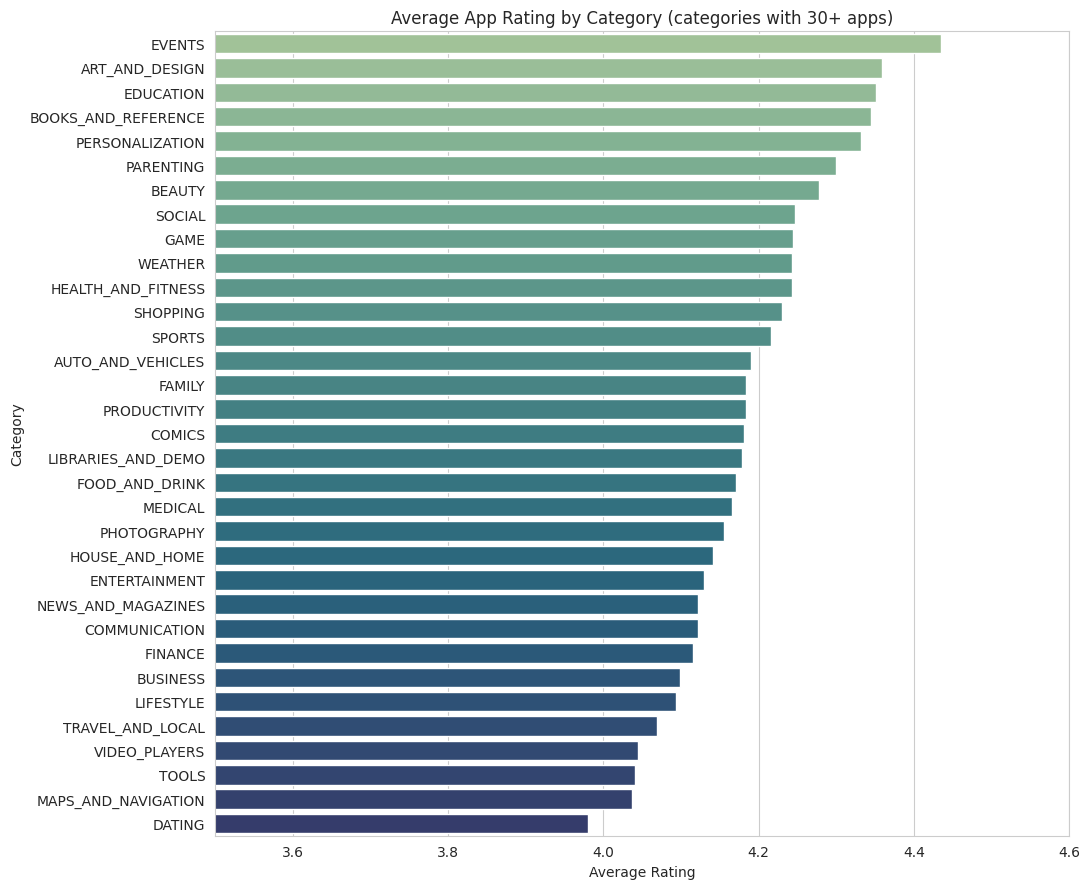

In [25]:
cat_counts_for_rating = apps_clean["Category"].value_counts()
valid_categories = cat_counts_for_rating[cat_counts_for_rating >= 30].index
print(f"{len(valid_categories)} of {apps_clean['Category'].nunique()} categories meet the 30-app minimum and are included below.")

category_ratings = (
    apps_clean[apps_clean["Category"].isin(valid_categories)]
    .groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 9))
sns.barplot(x=category_ratings.values, y=category_ratings.index, hue=category_ratings.index, palette="crest", legend=False)
plt.title("Average App Rating by Category (categories with 30+ apps)")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.xlim(3.5, 4.6)
plt.tight_layout()
plt.savefig("outputs/screenshots/05_average_rating_by_category.png", dpi=120)
plt.show()

In [26]:
print("Top 5 by average rating:")
print(category_ratings.head(5))
print()
print("Bottom 5 by average rating:")
print(category_ratings.tail(5))

Top 5 by average rating:
Category
EVENTS                 4.435556
ART_AND_DESIGN         4.359322
EDUCATION              4.351429
BOOKS_AND_REFERENCE    4.344970
PERSONALIZATION        4.332215
Name: Rating, dtype: float64

Bottom 5 by average rating:
Category
TRAVEL_AND_LOCAL       4.069519
VIDEO_PLAYERS          4.044966
TOOLS                  4.040278
MAPS_AND_NAVIGATION    4.036441
DATING                 3.980451
Name: Rating, dtype: float64


### Observation

**EVENTS** (4.44), **ART_AND_DESIGN** (4.36), and **EDUCATION** (4.35) have the highest average ratings among categories with sufficient sample size. **DATING** (3.98), **MAPS_AND_NAVIGATION** (4.04), and **TOOLS** (4.04) have the lowest. The spread between the best- and worst-rated categories is relatively narrow (under half a star), suggesting rating alone doesn't vary dramatically by category — but DATING standing out as the lowest-rated, larger category is worth noting for anyone considering that space.

## 8. App Size vs Installs

Is there a relationship between how large an app is and how many installs it has?

Apps with both Size and Installs available: 8431


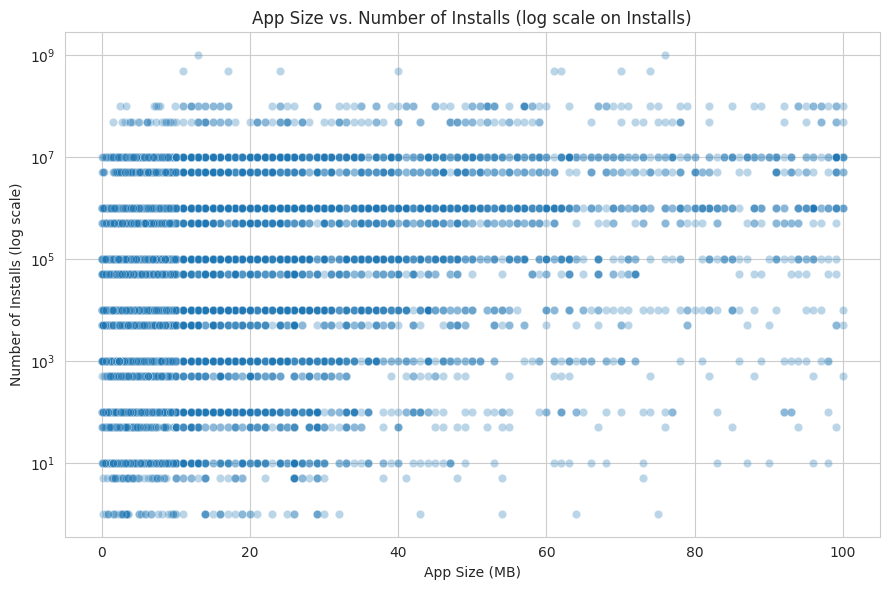

In [27]:
size_installs = apps_clean.dropna(subset=["Size_MB", "Installs"])
print(f"Apps with both Size and Installs available: {len(size_installs)}")

plt.figure(figsize=(9, 6))
sns.scatterplot(data=size_installs, x="Size_MB", y="Installs", alpha=0.3)
plt.yscale("log")
plt.title("App Size vs. Number of Installs (log scale on Installs)")
plt.xlabel("App Size (MB)")
plt.ylabel("Number of Installs (log scale)")
plt.tight_layout()
plt.savefig("outputs/screenshots/06_size_vs_installs.png", dpi=120)
plt.show()

In [28]:
corr_raw = size_installs["Size_MB"].corr(size_installs["Installs"])
corr_log = size_installs["Size_MB"].corr(np.log1p(size_installs["Installs"]))
print(f"Pearson correlation (Size_MB vs raw Installs):      r = {corr_raw:.3f}")
print(f"Pearson correlation (Size_MB vs log-scaled Installs): r = {corr_log:.3f}")

Pearson correlation (Size_MB vs raw Installs):      r = 0.134
Pearson correlation (Size_MB vs log-scaled Installs): r = 0.300


### Observation

The correlation is weak-to-very-weak in both forms (r ≈ 0.13 on raw Installs, r ≈ 0.30 even after log-scaling Installs to account for its extreme spread). Larger apps do *not* show a strong tendency toward either more or fewer installs — the scatter plot backs this up, showing installs spread widely across the whole size range with no clear trend line. **This is a weak association at best, and correlation here does not imply causation** — plenty of other factors (category, marketing, app quality, how long the app has been available) plausibly matter far more than raw file size.

## 9. Free vs Paid Apps

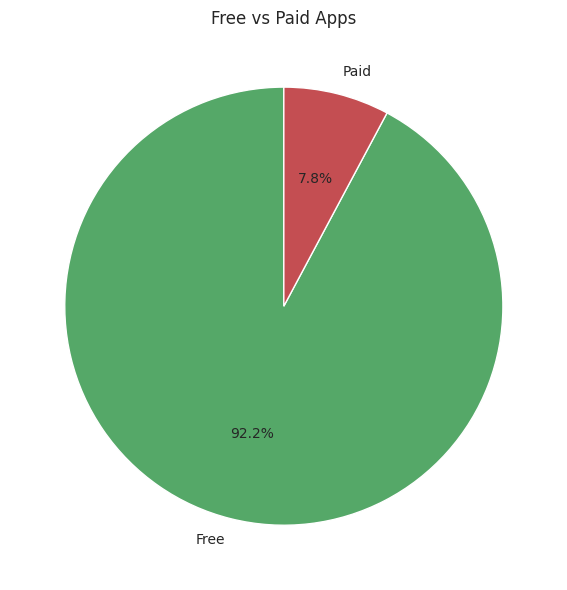

Type
Free    8904
Paid     754
Name: count, dtype: int64
Type
Free    92.2
Paid     7.8
Name: proportion, dtype: float64


In [29]:
type_counts = apps_clean["Type"].value_counts()
type_pct = apps_clean["Type"].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 6))
plt.pie(type_counts.values, labels=type_counts.index, autopct="%1.1f%%", colors=["#55A868", "#C44E52"], startangle=90)
plt.title("Free vs Paid Apps")
plt.tight_layout()
plt.savefig("outputs/screenshots/07_free_vs_paid.png", dpi=120)
plt.show()

print(type_counts)
print(type_pct.round(1))

### Observation

**Free apps dominate overwhelmingly**: 8,904 apps (92.2%) are free, versus only 754 (7.8%) paid. This confirms that the free-to-download, monetize-through-other-means model (ads, in-app purchases, subscriptions — none of which this dataset directly measures) is the standard approach on the Play Store, not the exception. A developer defaulting to an upfront price point is choosing a distinctly minority strategy.

## 10. Paid App Price Analysis

In [30]:
paid_apps = apps_clean[apps_clean["Type"] == "Paid"]
print(f"Number of paid apps: {len(paid_apps)}")
paid_apps["Price"].agg(["min", "max", "mean", "median"])

Number of paid apps: 754


min         0.990000
max       400.000000
mean       14.055902
median      2.990000
Name: Price, dtype: float64

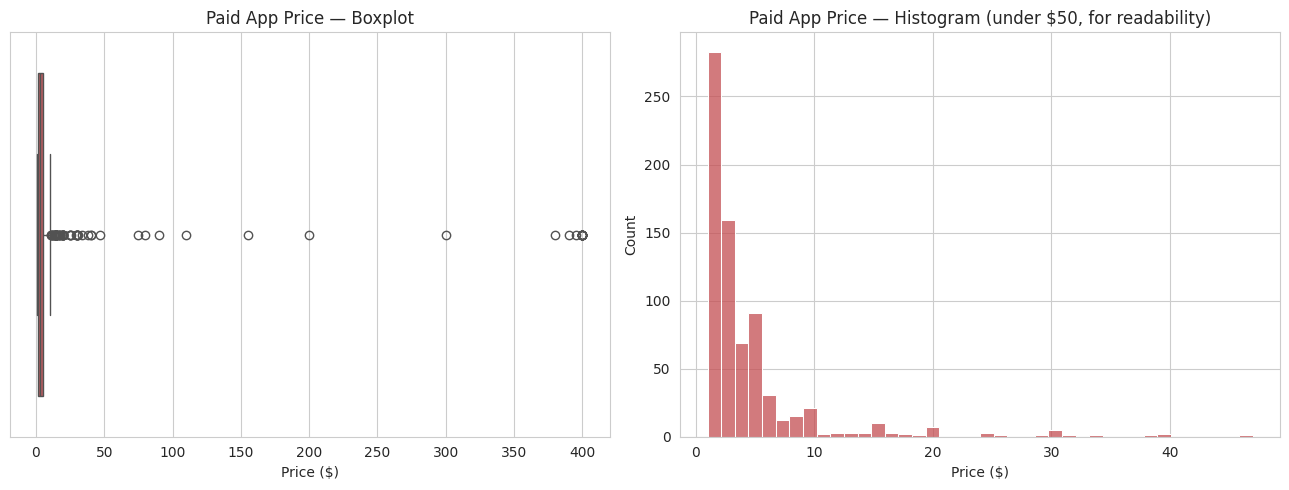

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(x=paid_apps["Price"], ax=axes[0], color="#C44E52")
axes[0].set_title("Paid App Price — Boxplot")
axes[0].set_xlabel("Price ($)")

sns.histplot(paid_apps[paid_apps["Price"] < 50]["Price"], bins=40, ax=axes[1], color="#C44E52")
axes[1].set_title("Paid App Price — Histogram (under $50, for readability)")
axes[1].set_xlabel("Price ($)")

plt.tight_layout()
plt.savefig("outputs/screenshots/08_paid_price_distribution.png", dpi=120)
plt.show()

In [32]:
print("Most expensive paid apps:")
print(paid_apps.sort_values("Price", ascending=False)[["App", "Category", "Price"]].head(5))

Most expensive paid apps:
                                 App   Category   Price
4367        I'm Rich - Trump Edition  LIFESTYLE  400.00
5362                   I Am Rich Pro     FAMILY  399.99
5373              I AM RICH PRO PLUS    FINANCE  399.99
5359              I am rich(premium)    FINANCE  399.99
5364  I am rich (Most expensive app)    FINANCE  399.99


### Observation

Paid app prices are heavily right-skewed and cluster tightly at the low end: the median price is just $2.99, and the 25th–75th percentile range is roughly $1.49–$4.99. The mean ($14.06) is pulled far above the median by a small number of extreme outliers — most notably several apps priced at $400 (visible in the boxplot as isolated points far right of the main cluster). These extreme prices are kept in the analysis rather than removed, since there's no evidence they're data errors — some niche professional or "novelty/prank" apps genuinely do list at unusual prices on the Play Store. The clear takeaway: **the realistic price range for a typical paid app is a few dollars, not tens or hundreds.**

## 11. Revenue Estimation

A simple gross revenue proxy: `Estimated_Revenue = Price × Installs`.

**This is only an estimated gross revenue proxy, not verified actual revenue.** It does not account for Google Play's revenue share, refunds, taxes, regional pricing, subscriptions, in-app purchases, or the fact that `Installs` is a rounded lower-bound range rather than an exact count. It should be read as "roughly how much money changed hands at list price for this many installs," nothing more precise than that.

In [33]:
apps_clean["Estimated_Revenue"] = apps_clean["Price"] * apps_clean["Installs"]

top_revenue_apps = apps_clean.sort_values("Estimated_Revenue", ascending=False)[["App", "Category", "Price", "Installs", "Estimated_Revenue"]].head(10)
top_revenue_apps

,App,Category,Price,Installs,Estimated_Revenue
2241,Minecraft,FAMILY,6.99,10000000,69900000.0
5351,I am rich,LIFESTYLE,399.99,100000,39999000.0
5356,I Am Rich Premium,FINANCE,399.99,50000,19999500.0
4034,Hitman Sniper,GAME,0.99,10000000,9900000.0
7417,Grand Theft Auto: San Andreas,GAME,6.99,1000000,6990000.0
2912,Facetune - For Free,PHOTOGRAPHY,5.99,1000000,5990000.0
5578,Sleep as Android Unlock,LIFESTYLE,5.99,1000000,5990000.0
8804,DraStic DS Emulator,GAME,4.99,1000000,4990000.0
4367,I'm Rich - Trump Edition,LIFESTYLE,400.00,10000,4000000.0
5354,I am Rich Plus,FAMILY,399.99,10000,3999900.0


### Observation

The apps with the highest estimated revenue proxy are almost all apps with a modest price ($1–10) combined with an enormous install count — confirming that under this proxy, **install volume matters far more than price point**. A $400 app with a handful of installs contributes negligibly compared to a $0.99 app installed a million times.

## 12. Revenue by Category

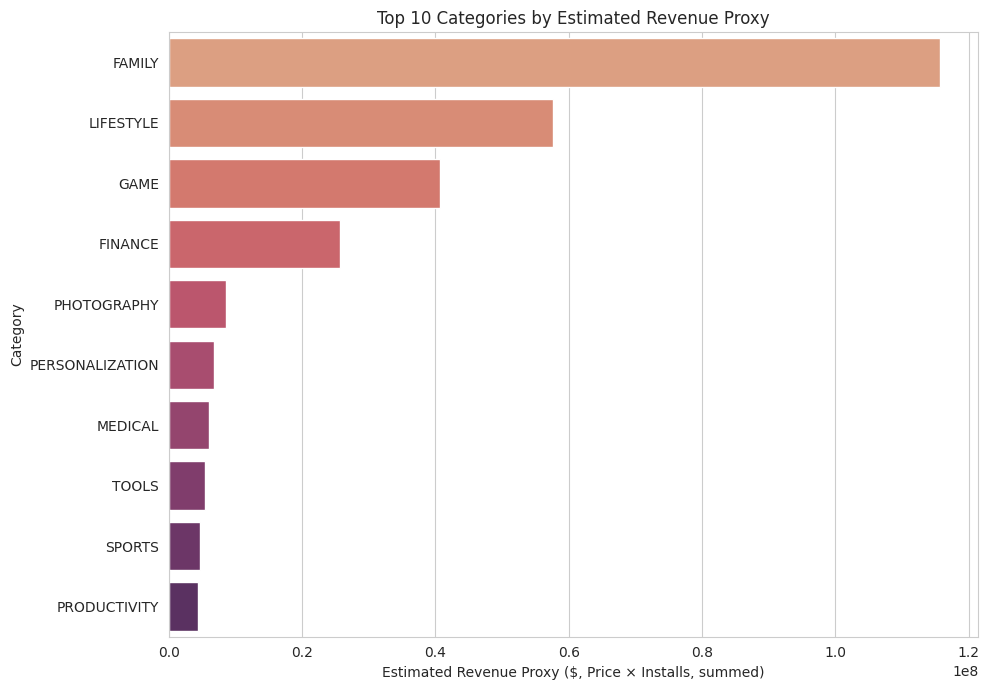

In [34]:
category_revenue = apps_clean.groupby("Category")["Estimated_Revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=category_revenue.head(10).values, y=category_revenue.head(10).index, hue=category_revenue.head(10).index, palette="flare", legend=False)
plt.title("Top 10 Categories by Estimated Revenue Proxy")
plt.xlabel("Estimated Revenue Proxy ($, Price × Installs, summed)")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("outputs/screenshots/09_revenue_by_category.png", dpi=120)
plt.show()

In [35]:
category_revenue.head(10)

Category
FAMILY             1.156808e+08
LIFESTYLE          5.758394e+07
GAME               4.068864e+07
FINANCE            2.572668e+07
PHOTOGRAPHY        8.547768e+06
PERSONALIZATION    6.796948e+06
MEDICAL            5.956237e+06
TOOLS              5.464821e+06
SPORTS             4.706212e+06
PRODUCTIVITY       4.313375e+06
Name: Estimated_Revenue, dtype: float64

### Observation

**FAMILY** leads by a wide margin (~$115.7M in the proxy), followed by **LIFESTYLE** (~$57.6M) and **GAME** (~$40.7M). Given that FAMILY and GAME are also the two largest categories by app count (Step 5), their top revenue ranking is driven substantially by **sheer volume of paid apps and installs**, not by unusually high prices — this is a combination of many paid apps *and* high install counts, rather than a few expensive outliers. LIFESTYLE's strong second-place showing despite a smaller app count is more interesting and suggests either higher-than-average pricing or a few exceptionally high-install paid apps in that category specifically.

## 13. User Review Data Cleaning

Returning to the separate Reviews dataset. The review-text column is `Translated_Review`. Rows with no text (missing, or blank after stripping whitespace) carry no usable sentiment signal and are excluded from the sentiment analysis that follows.

In [36]:
n_reviews_start = len(reviews)

reviews_clean = reviews.dropna(subset=["Translated_Review"]).copy()
reviews_clean = reviews_clean[reviews_clean["Translated_Review"].str.strip() != ""]

n_removed = n_reviews_start - len(reviews_clean)
print(f"Removed {n_removed} rows with no usable review text ({n_removed/n_reviews_start:.1%}).")
print(f"Usable reviews remaining: {len(reviews_clean)}")

# Duplicate exact reviews
n_before = len(reviews_clean)
reviews_clean = reviews_clean.drop_duplicates()
print(f"Removed {n_before - len(reviews_clean)} exact duplicate review rows.")

Removed 26868 rows with no usable review text (41.8%).
Usable reviews remaining: 37427
Removed 7735 exact duplicate review rows.


In [37]:
# Update the cleaning summary table now that both datasets are cleaned
cleaning_summary = pd.DataFrame({
    "Dataset": ["Apps", "Reviews"],
    "Original Rows": [len(apps), n_reviews_start],
    "Cleaned Rows": [len(apps_clean), len(reviews_clean)],
    "Rows Removed": [len(apps) - len(apps_clean), n_reviews_start - len(reviews_clean)],
})
cleaning_summary

,Dataset,Original Rows,Cleaned Rows,Rows Removed
0,Apps,10841,9658,1183
1,Reviews,64295,29692,34603


## 14. Sentiment Analysis

Using **VADER** (chosen over TextBlob, since it's built for short informal text like these reviews), we compute a compound sentiment score for each review, ranging from -1 (most negative) to +1 (most positive).

**Thresholding strategy:** we use VADER's own standard, documented thresholds rather than an arbitrary cutoff:
- `compound >= 0.05` → **Positive**
- `compound <= -0.05` → **Negative**
- otherwise → **Neutral**

In [38]:
reviews_clean["sentiment_score"] = reviews_clean["Translated_Review"].apply(
    lambda x: sia.polarity_scores(str(x))["compound"]
)

def classify_sentiment(compound):
    if compound >= 0.05:
        return "Positive"
    elif compound <= -0.05:
        return "Negative"
    else:
        return "Neutral"

reviews_clean["Sentiment_Category"] = reviews_clean["sentiment_score"].apply(classify_sentiment)
reviews_clean[["App", "Translated_Review", "sentiment_score", "Sentiment_Category"]].head()

,App,Translated_Review,sentiment_score,Sentiment_Category
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,0.9531,Positive
1,10 Best Foods for You,This help eating healthy exercise regular basis,0.6597,Positive
3,10 Best Foods for You,Works great especially going grocery store,0.6249,Positive
4,10 Best Foods for You,Best idea us,0.6369,Positive
5,10 Best Foods for You,Best way,0.6369,Positive


### Observation

Note: the dataset ships with its own pre-computed `Sentiment` column (from an earlier TextBlob-based analysis by the dataset's original authors). We've independently re-computed sentiment with VADER rather than trusting that column blindly — this is our own, reproducible result, not a repetition of someone else's labels.

## 15. Sentiment Distribution

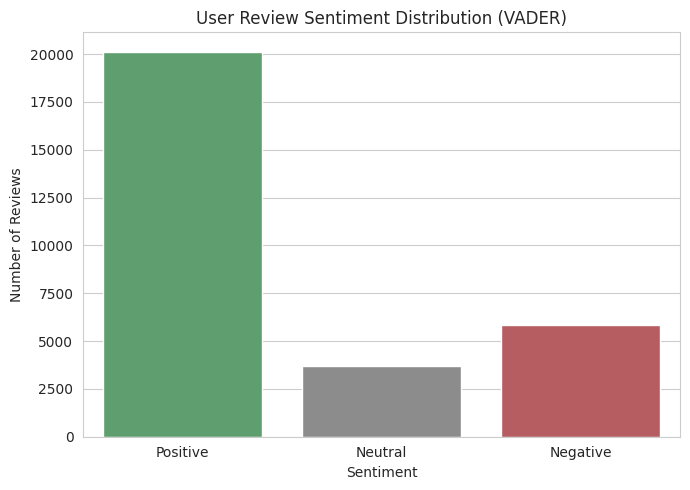

Sentiment_Category
Positive    20129
Negative     5852
Neutral      3711
Name: count, dtype: int64
Sentiment_Category
Positive    67.8
Negative    19.7
Neutral     12.5
Name: proportion, dtype: float64


In [39]:
sentiment_counts = reviews_clean["Sentiment_Category"].value_counts()
sentiment_pct = reviews_clean["Sentiment_Category"].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))
sns.countplot(data=reviews_clean, x="Sentiment_Category", hue="Sentiment_Category",
              order=["Positive", "Neutral", "Negative"], palette={"Positive": "#55A868", "Neutral": "#8C8C8C", "Negative": "#C44E52"},
              legend=False)
plt.title("User Review Sentiment Distribution (VADER)")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig("outputs/screenshots/10_sentiment_distribution.png", dpi=120)
plt.show()

print(sentiment_counts)
print(sentiment_pct.round(1))

### Observation

User sentiment is **overwhelmingly positive**: 67.8% of reviews are classified Positive, versus 19.7% Negative and 12.5% Neutral. This means the people who bother to leave a written review skew strongly toward satisfied users — worth remembering when interpreting review text, since it likely doesn't represent the full silent population of app users equally (people who are mildly satisfied or indifferent are less likely to write a review at all).

## 16. Sentiment by App Category

Connecting reviews to categories via the shared `App` field.

In [40]:
reviews_with_category = reviews_clean.merge(apps_clean[["App", "Category"]], on="App", how="left")

n_unmatched = reviews_with_category["Category"].isnull().sum()
print(f"Unmatched reviews after merge (app not found in cleaned Apps dataset): {n_unmatched} of {len(reviews_with_category)} ({n_unmatched/len(reviews_with_category):.1%})")

reviews_with_category = reviews_with_category.dropna(subset=["Category"])
print(f"Reviews retained with a matched category: {len(reviews_with_category)}")

Unmatched reviews after merge (app not found in cleaned Apps dataset): 1442 of 29692 (4.9%)
Reviews retained with a matched category: 28250


Some reviews don't match any app in the cleaned Apps dataset — most likely because that app was one of the duplicate/corrupted rows removed during cleaning, or a name-formatting mismatch between the two source files. These unmatched reviews are excluded from category-level sentiment, since they can't be reliably attributed.

33 of 33 categories meet the 30-review minimum.


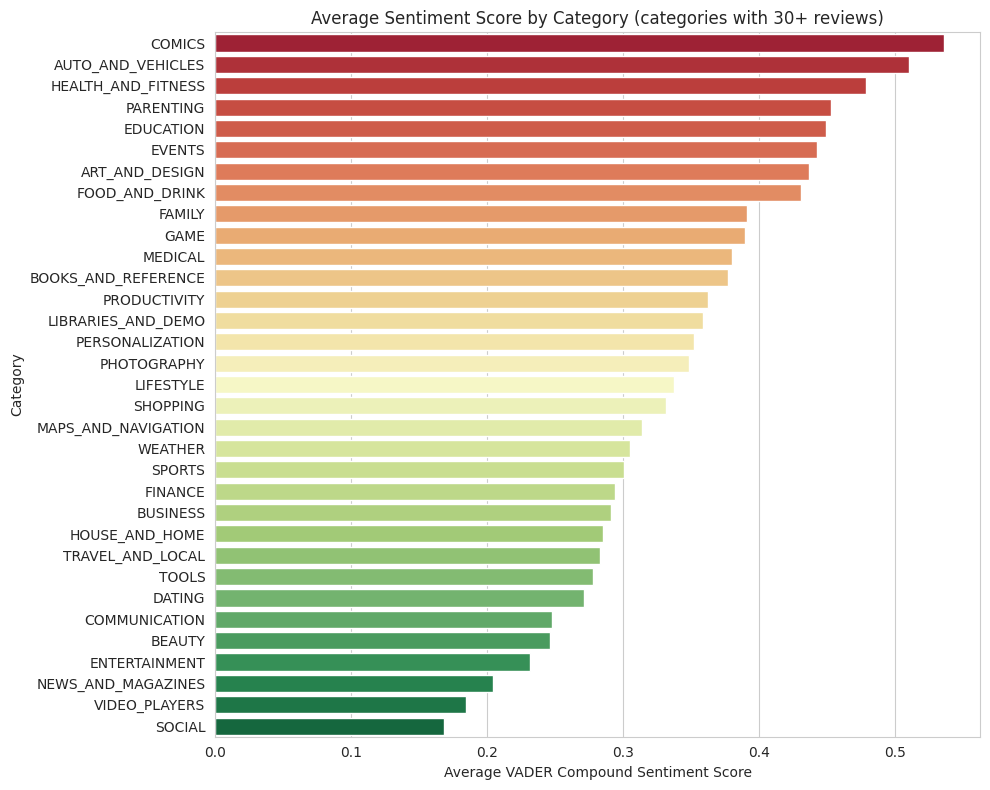

In [41]:
category_sentiment = reviews_with_category.groupby("Category")["sentiment_score"].agg(["mean", "count"]).rename(columns={"mean": "Avg_Sentiment", "count": "Review_Count"})
category_sentiment = category_sentiment.sort_values("Avg_Sentiment", ascending=False)

# Require a minimum number of reviews before including a category, same logic as Step 7
valid_sentiment_cats = category_sentiment[category_sentiment["Review_Count"] >= 30]
print(f"{len(valid_sentiment_cats)} of {len(category_sentiment)} categories meet the 30-review minimum.")

plt.figure(figsize=(10, 8))
sns.barplot(x=valid_sentiment_cats["Avg_Sentiment"], y=valid_sentiment_cats.index, hue=valid_sentiment_cats.index, palette="RdYlGn", legend=False)
plt.title("Average Sentiment Score by Category (categories with 30+ reviews)")
plt.xlabel("Average VADER Compound Sentiment Score")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("outputs/screenshots/11_sentiment_by_category.png", dpi=120)
plt.show()

## 17. Most Positive and Negative Categories

(Continuing to require at least 30 matched reviews per category, for the same reliability reason as Step 7.)

In [42]:
print("Top 5 categories by average sentiment:")
print(valid_sentiment_cats.head(5))
print()
print("Bottom 5 categories by average sentiment:")
print(valid_sentiment_cats.tail(5))

Top 5 categories by average sentiment:
                    Avg_Sentiment  Review_Count
Category                                       
COMICS                   0.535871            45
AUTO_AND_VEHICLES        0.510319           283
HEALTH_AND_FITNESS       0.479149          1621
PARENTING                0.452984           256
EDUCATION                0.449490           519

Bottom 5 categories by average sentiment:
                    Avg_Sentiment  Review_Count
Category                                       
BEAUTY                   0.246506           317
ENTERTAINMENT            0.231839           701
NEWS_AND_MAGAZINES       0.204705           733
VIDEO_PLAYERS            0.184835           326
SOCIAL                   0.168463           661


In [43]:
positive_pct_by_cat = (
    reviews_with_category[reviews_with_category["Category"].isin(valid_sentiment_cats.index)]
    .groupby("Category")["Sentiment_Category"]
    .apply(lambda x: (x == "Positive").mean() * 100)
    .sort_values(ascending=False)
)
print("Top 5 by % positive reviews:")
print(positive_pct_by_cat.head(5).round(1))
print()
print("Bottom 5 by % positive reviews:")
print(positive_pct_by_cat.tail(5).round(1))

Top 5 by % positive reviews:
Category
COMICS                86.7
AUTO_AND_VEHICLES     82.0
EVENTS                79.5
HEALTH_AND_FITNESS    77.9
EDUCATION             76.3
Name: Sentiment_Category, dtype: float64

Bottom 5 by % positive reviews:
Category
BEAUTY                60.6
ENTERTAINMENT         57.9
NEWS_AND_MAGAZINES    57.6
VIDEO_PLAYERS         55.8
SOCIAL                54.9
Name: Sentiment_Category, dtype: float64


### Observation

**COMICS** (avg score 0.54, 86.7% positive), **AUTO_AND_VEHICLES** (0.51, 82.0% positive), and **HEALTH_AND_FITNESS** (0.48, 77.9% positive) have the strongest average sentiment. **SOCIAL** (0.17, 54.9% positive), **VIDEO_PLAYERS** (0.18, 55.8% positive), and **NEWS_AND_MAGAZINES** (0.20, 57.6% positive) have the weakest — still net-positive on average, but with meaningfully more mixed and negative feedback than other categories. It's notable that SOCIAL and NEWS_AND_MAGAZINES, both content-driven categories where users often have strong opinions about specific content or moderation decisions, land at the bottom — consistent with those categories naturally attracting more polarized reactions than, say, a COMICS reader app.

## 18. Interactive Visualization (Plotly)

An interactive scatter plot of Rating vs Installs, sized by review count and colored by category, so a developer can hover over individual apps, zoom into a crowded region, and toggle categories on/off via the legend — genuinely useful for exploring where a specific app idea might fit, not just a decorative chart.

In [44]:
plot_data = apps_clean.dropna(subset=["Rating", "Installs", "Reviews"])
plot_data = plot_data[plot_data["Category"].isin(category_counts.head(12).index)]  # top 12 categories, for legend readability

fig = px.scatter(
    plot_data,
    x="Rating",
    y="Installs",
    size="Reviews",
    color="Category",
    hover_name="App",
    log_y=True,
    title="Interactive: App Ratings vs Installs (bubble size = review count, top 12 categories)",
    labels={"Installs": "Installs (log scale)", "Rating": "Rating"}
)
fig.update_layout(height=650)
fig.write_html("outputs/screenshots/12_interactive_visualization.html")
fig.show()

### Observation

The chart is filtered to the 12 largest categories for legend readability, and confirms visually what the earlier sections found numerically: most apps cluster in the 4.0–4.5 rating band regardless of install count, and the largest bubbles (highest review counts) are concentrated in a handful of very popular apps per category rather than spread evenly — consistent with the heavily right-skewed install distribution seen throughout this analysis.

## 19. Developer Market Insights

**What should a developer consider before launching a new Android app?** Three insights grounded in the actual results above:

### 1. Category choice is a genuine trade-off between competition and audience size
FAMILY and GAME are by far the most crowded categories (1,875 and 945 apps respectively) — a new app there competes for attention against nearly 2,000 existing entries. Smaller categories like BEAUTY (53 apps) or COMICS (56 apps) face far less direct competition, and COMICS specifically also shows the strongest user sentiment (86.7% positive) of any category — a combination worth investigating further for a developer without a strong pull toward FAMILY/GAME specifically.

### 2. The free-with-monetization model is the dataset's overwhelming norm
92.2% of apps are free; only 7.8% charge upfront. Combined with the revenue analysis showing that install volume drives the estimated revenue proxy far more than price point does, this dataset supports the free-to-download approach as the default expectation for new entrants — charging upfront is the exception, not a safer default.

### 3. Category and content strategy affect user sentiment more than app size does
App size shows only a weak correlation with installs (r ≈ 0.13–0.30) — optimizing purely for a small download size is not, by itself, a strong lever for adoption in this data. Category matters more: sentiment ranges from ~0.17 (SOCIAL) to ~0.54 (COMICS) average compound score across categories, a meaningful spread that likely reflects how much a category's content is subject to user disagreement (news, social feeds) versus more universally well-received utility (auto/vehicle tools, health trackers).

## 20. Limitations

- **Dataset age**: this is a historical snapshot (apps last updated mostly in 2017–2018), not a live view of the current Play Store — category saturation, pricing norms, and sentiment could all look different today.
- **Missing values**: 1,463 apps have no Rating; these were preserved as missing rather than imputed, but any rating-based analysis is implicitly working from the subset of apps that *do* have enough reviews to generate one.
- **Duplicate handling**: duplicate `App` entries were resolved by keeping the highest-`Reviews` version — a reasonable but not the only defensible choice; a different tie-breaking rule could shift category counts slightly.
- **Revenue is an estimated proxy, not actual revenue**: `Price × Installs` ignores Google's revenue share, refunds, regional pricing, subscriptions, and in-app purchases entirely, and `Installs` itself is a rounded range, not an exact count.
- **Reviews may not represent all users**: only people who chose to write a review are represented, and the 68% positive skew suggests satisfied users are likelier to do so than neutral ones — silent, indifferent users are effectively invisible in the sentiment analysis.
- **Automated sentiment analysis is not equivalent to human judgment**: VADER can misinterpret sarcasm, mixed reviews, or domain-specific language, and a compound score is a simplification of genuinely nuanced feedback.
- **Category-level rating and sentiment comparisons used a minimum sample size (30 apps/reviews)** specifically to avoid small-sample categories producing misleadingly extreme averages — but even at 30, some spread remains just from sample size differences across categories.
- **Correlation does not imply causation** anywhere in this analysis, including the Size-vs-Installs result — a weak correlation only describes association, not what's causing what.

## 21. Final Conclusion

This analysis cleaned and examined two real Google Play Store datasets — ~10,800 apps and ~64,000 user reviews — to understand the Android app market end-to-end.

**FAMILY and GAME** contain the most apps and appear most saturated; **EVENTS, ART_AND_DESIGN, PARENTING, COMICS, and BEAUTY** are comparatively uncrowded. The **rating distribution** is concentrated between 4.0–4.5 stars with a long low-rating tail, and **EVENTS, ART_AND_DESIGN, and EDUCATION** have the highest category-average ratings among categories with enough apps to compare reliably. **App size shows only a weak relationship with installs** (r ≈ 0.13–0.30) — bigger or smaller isn't a strong lever on its own. **Free apps vastly outnumber paid ones** (92.2% vs 7.8%), and the **estimated revenue proxy** is led by FAMILY, LIFESTYLE, and GAME — driven mainly by install volume rather than price. **User sentiment is broadly positive** (67.8% of reviews), with **COMICS, AUTO_AND_VEHICLES, and HEALTH_AND_FITNESS** showing the strongest sentiment and **SOCIAL, VIDEO_PLAYERS, and NEWS_AND_MAGAZINES** the weakest.

The three developer insights in Section 19 — competition vs. audience-size trade-offs in category choice, the dominance of the free monetization model, and category/content strategy mattering more for sentiment than raw app size — are offered as a starting point for someone deciding where and how to launch a new Android app, with the limitations above kept firmly in mind rather than treated as certainty.